# M82-like Multiphase Wind: User Notebook

This notebook runs a single M82-like model and makes the standard plots using built-in helpers from `multiphasegalacticwind.plotting`.

Workflow:
1. Edit the user parameters in the next code cell (especially the `eta` values).
2. Run all cells.
3. Inspect the plots and summary diagnostics.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from multiphasegalacticwind import (
    WindModel,
    setup_plotting_style,
    plot_wind_solution,
    plot_profiles,
    plot_column_density_distribution,
)
from multiphasegalacticwind.constants import Msun

setup_plotting_style()

## User Parameters (Edit Here)

These are the key knobs to change between runs.

Requested default physics:
- `SFR = 20 Msun/yr`, `v_circ = 150 km/s`
- `eta_M_hot = 0.1`, `eta_M_cold_tot = 0.2`, `eta_E_hot = 1.0`
- cloud mass range `1` to `1e6 Msun`
- `alpha_cloud = 2` so that `dN/dlogM ~ M^-1`
- `N_cloud_bins = 13`

In [9]:
# Galaxy-scale parameters
SFR_MSUN_PER_YR = 20.0
V_CIRC_KMS = 150.0

# Loading factors (primary user controls)
ETA_M_HOT = 0.1
ETA_M_COLD_TOT = 0.2
ETA_E_HOT = 1.0

# Cloud mass spectrum
M_CLOUD_MIN_MSUN = 1.0
M_CLOUD_MAX_MSUN = 1.0e6
ALPHA_CLOUD = 2.0
N_CLOUD_BINS = 13

# Integration/observable ranges
R_STAR_KPC = 0.3
R_MAX_KPC = 30.0
# dN/dv is sensitive to this lower radial bound; using r_star avoids truncation artifacts.
R_MIN_OBS_KPC = R_STAR_KPC
R_MAX_OBS_KPC = 30.0

# Numerical tolerances
RTOL = 1e-6
ATOL = 1e-8

# Optional figure export
SAVE_PLOTS = False
PLOTS_DIR = "plots_m82_notebook"

print("Current run setup:")
print(f"  SFR = {SFR_MSUN_PER_YR:.1f} Msun/yr")
print(f"  v_circ = {V_CIRC_KMS:.1f} km/s")
print(f"  eta_M_hot = {ETA_M_HOT:.3f}")
print(f"  eta_M_cold_tot = {ETA_M_COLD_TOT:.3f}")
print(f"  eta_E_hot = {ETA_E_HOT:.3f}")
print(f"  alpha_cloud = {ALPHA_CLOUD:.1f} -> dN/dlogM ~ M^{1.0 - ALPHA_CLOUD:.1f}")
print(f"  cloud mass range = [{M_CLOUD_MIN_MSUN:.1f}, {M_CLOUD_MAX_MSUN:.1e}] Msun")
print(f"  cloud bins = {N_CLOUD_BINS}")

Current run setup:
  SFR = 20.0 Msun/yr
  v_circ = 150.0 km/s
  eta_M_hot = 0.100
  eta_M_cold_tot = 0.200
  eta_E_hot = 1.000
  alpha_cloud = 2.0 -> dN/dlogM ~ M^-1.0
  cloud mass range = [1.0, 1.0e+06] Msun
  cloud bins = 13


In [10]:
model = WindModel(
    SFR=SFR_MSUN_PER_YR,
    v_circ=V_CIRC_KMS,
    eta_M=ETA_M_HOT,
    eta_M_cold_tot=ETA_M_COLD_TOT,
    eta_E=ETA_E_HOT,
    r_star_kpc=R_STAR_KPC,
    cloud_mass_range=(M_CLOUD_MIN_MSUN, M_CLOUD_MAX_MSUN),
    cloud_alpha=ALPHA_CLOUD,
    N_cloud_species=N_CLOUD_BINS,
    r_max_kpc=R_MAX_KPC,
    rtol=RTOL,
    atol=ATOL,
)

print("Model constructed. Initial cloud masses [Msun]:")
print(np.array2string(model.M_cloud0 / Msun, precision=3))

Model constructed. Initial cloud masses [Msun]:
[1.000e+00 3.162e+00 1.000e+01 3.162e+01 1.000e+02 3.162e+02 1.000e+03
 3.162e+03 1.000e+04 3.162e+04 1.000e+05 3.162e+05 1.000e+06]


In [11]:
solution = model.run()

print("Integration summary:")
print(f"  status = {solution.sol.status}")
print(f"  message = {solution.sol.message}")
print(f"  max radius reached = {solution.r[-1]:.2f} kpc")

if solution.r[-1] >= 10.0:
    print(f"  v(10 kpc) = {solution.v_at_10kpc:.1f} km/s")
    print(f"  Mdot/SFR(10 kpc) = {solution.mass_loading_at_10kpc:.3f}")

obs_r_max = min(R_MAX_OBS_KPC, float(solution.r[-1]))
if obs_r_max <= R_MIN_OBS_KPC:
    raise RuntimeError("Insufficient radial span for column-density diagnostics.")

moments = solution.calculate_velocity_moments(
    r_min_kpc=R_MIN_OBS_KPC,
    r_max_kpc=obs_r_max,
)
if "mean" in moments:
    print(f"  <v> = {moments['mean']:.1f} km/s")
    print(f"  sigma_v = {moments['dispersion']:.1f} km/s")

Integration summary:
  status = 0
  message = The solver successfully reached the end of the integration interval.
  max radius reached = 30.00 kpc
  v(10 kpc) = 1782.1 km/s
  Mdot/SFR(10 kpc) = 0.242
  <v> = 319.0 km/s
  sigma_v = 175.6 km/s


## Standard Plot Set

These panels use the package plotting API directly (`plotting.py`).

Note: `dN/dv` is sensitive to `R_MIN_OBS_KPC`. Starting too far out can introduce artificial edge features.


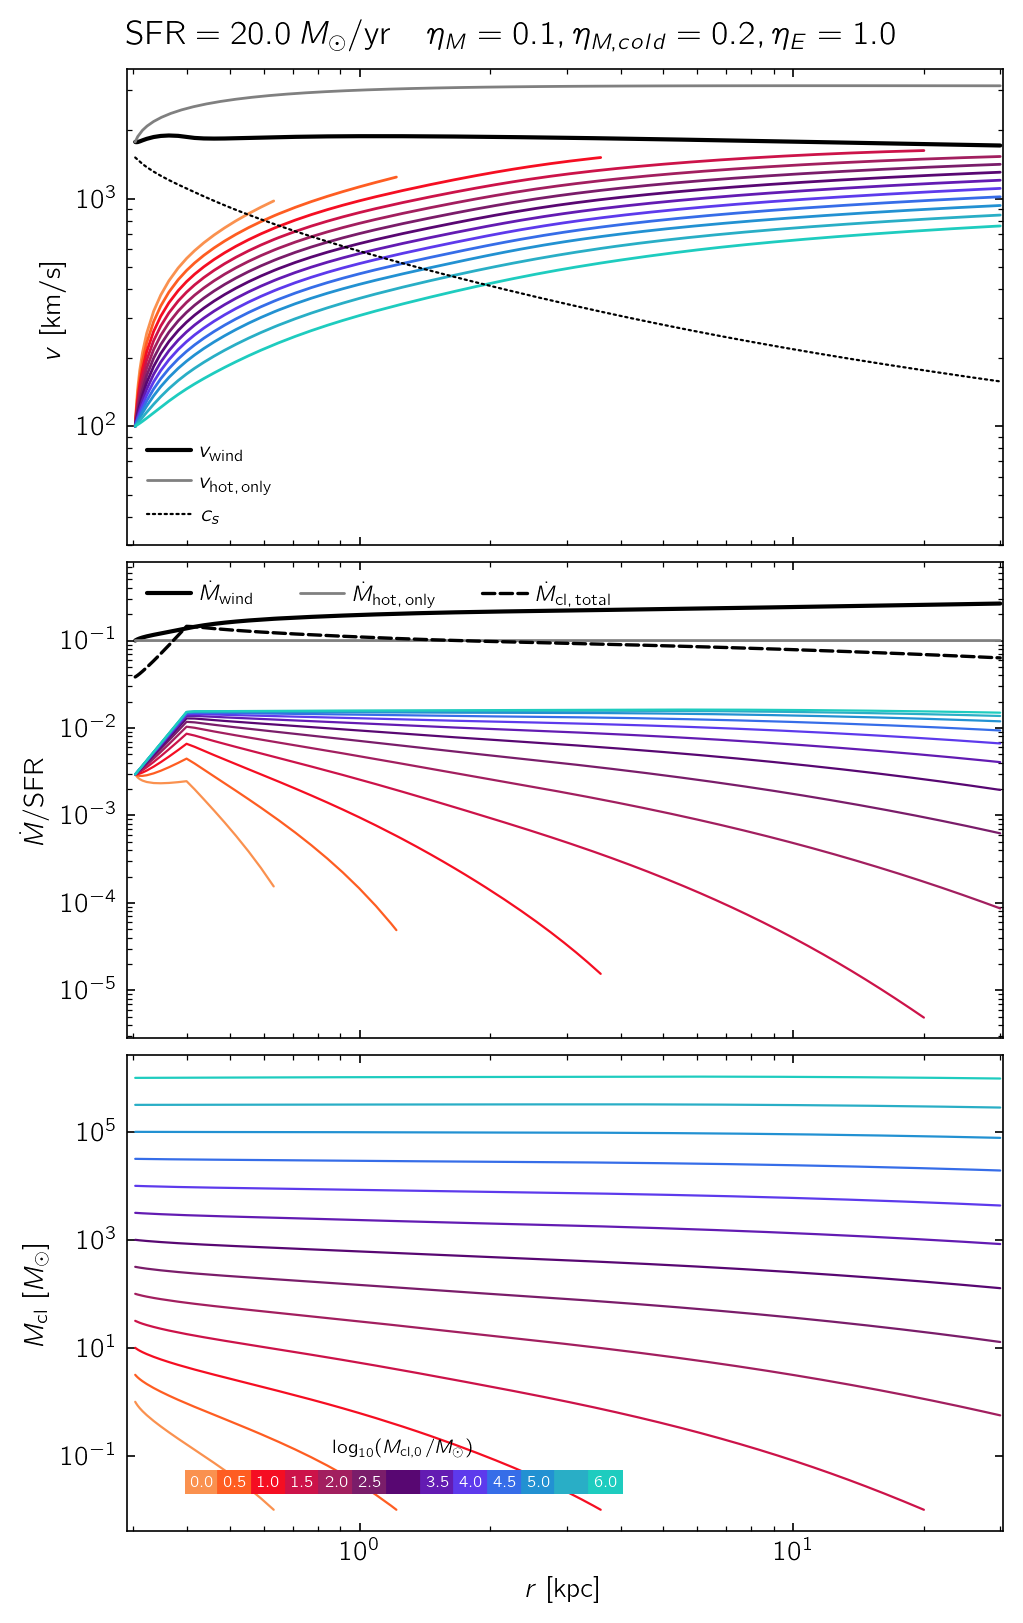

In [19]:
fig_wind, _ = plot_wind_solution(
    solution,
    show_hot_only=True,
    show_clouds=True,
    figsize=(5.0, 8.0),
)
fig_wind.suptitle(
    rf"${{\rm SFR}}={{{SFR_MSUN_PER_YR}}} \, M_\odot / {{\rm yr}} \quad  \eta_M={{{ETA_M_HOT}}}, \eta_{{M,cold}}={{{ETA_M_COLD_TOT}}}, \eta_E={{{ETA_E_HOT}}}$",
    # y=1.01,
)

if SAVE_PLOTS:
    os.makedirs(PLOTS_DIR, exist_ok=True)
    fig_wind.savefig(os.path.join(PLOTS_DIR, "m82_wind_solution.pdf"), dpi=300, bbox_inches="tight")

plt.show()

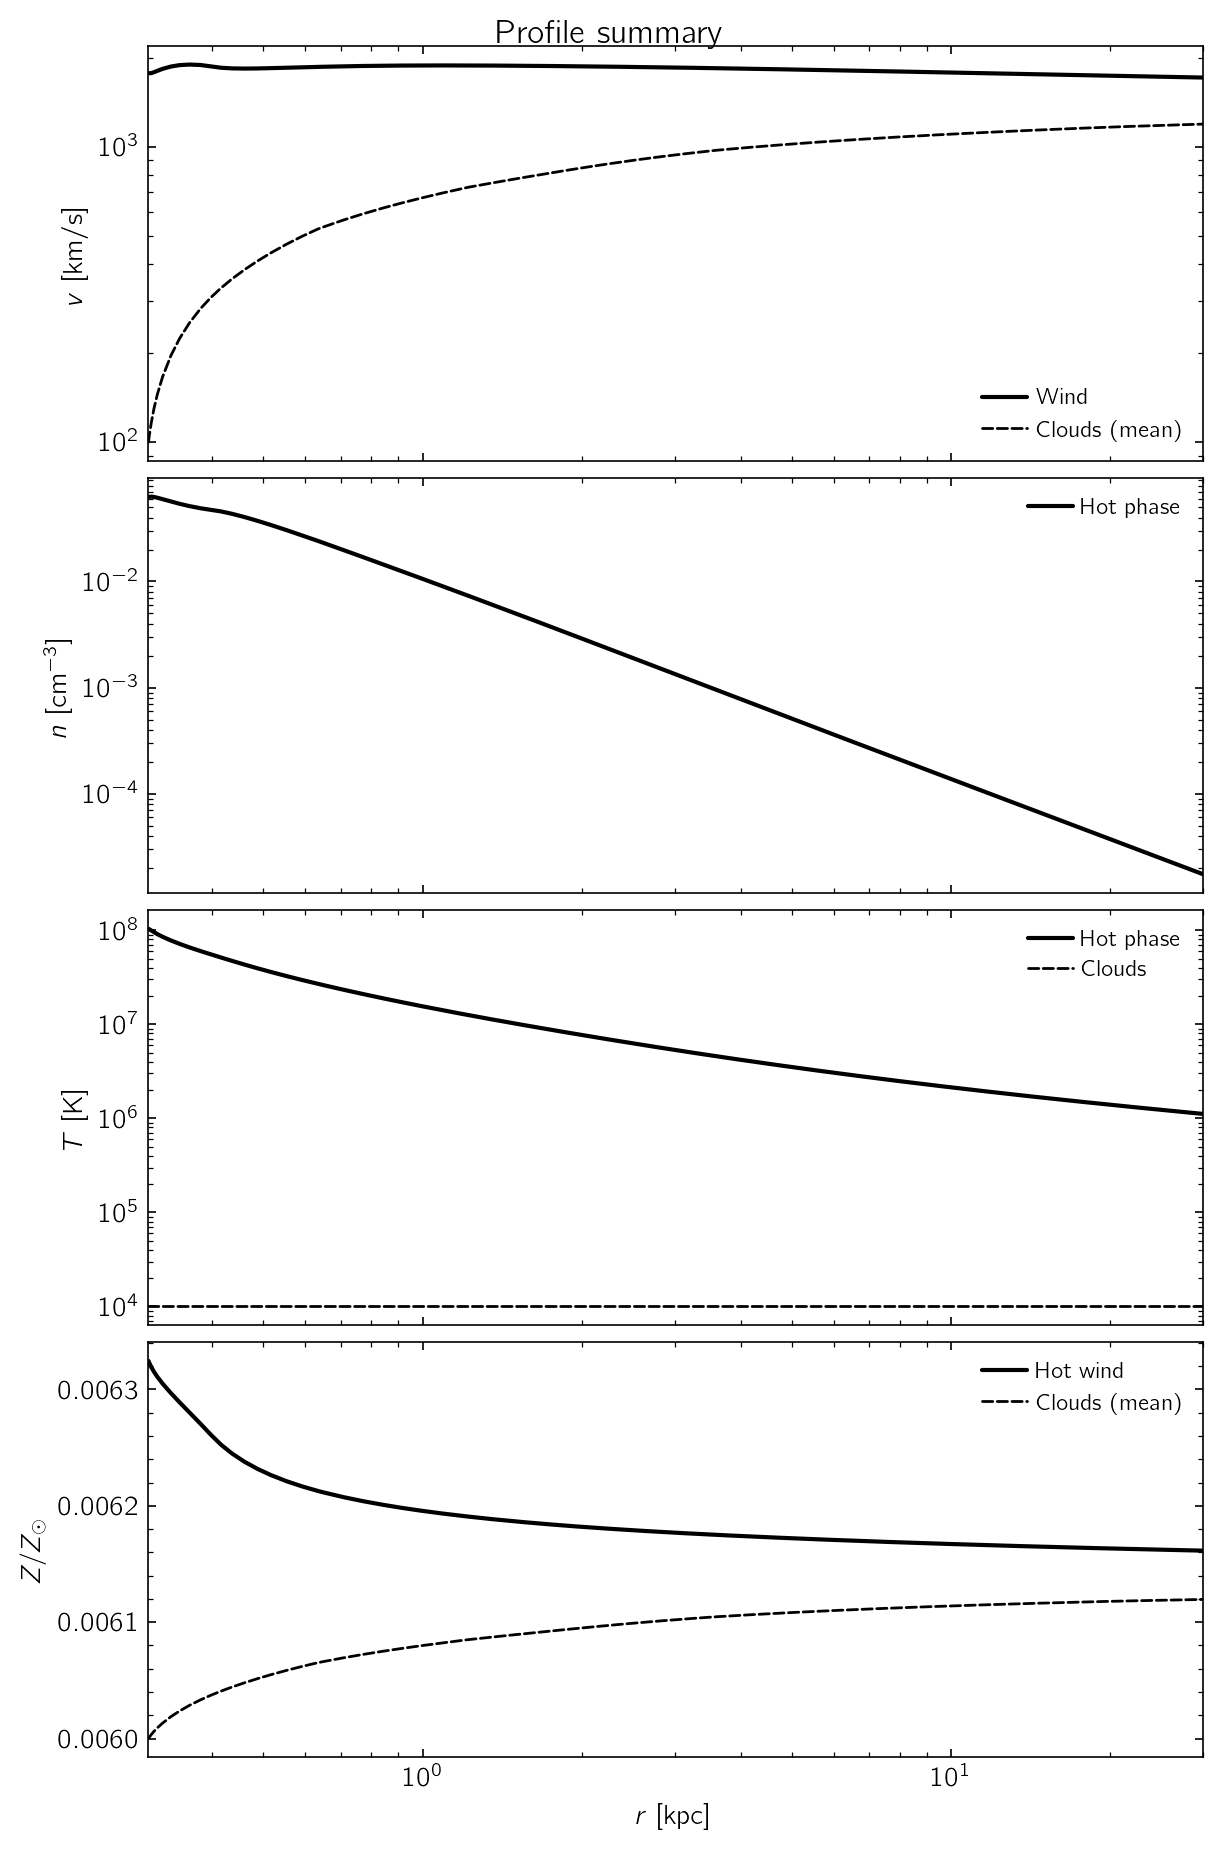

In [13]:
fig_profiles, _ = plot_profiles(
    solution,
    quantities=["velocity", "density", "temperature", "metallicity"],
    figsize=(6.0, 9.0),
)
fig_profiles.suptitle("Profile summary", y=1.01)

if SAVE_PLOTS:
    fig_profiles.savefig(os.path.join(PLOTS_DIR, "m82_profile_summary.pdf"), dpi=300, bbox_inches="tight")

plt.show()

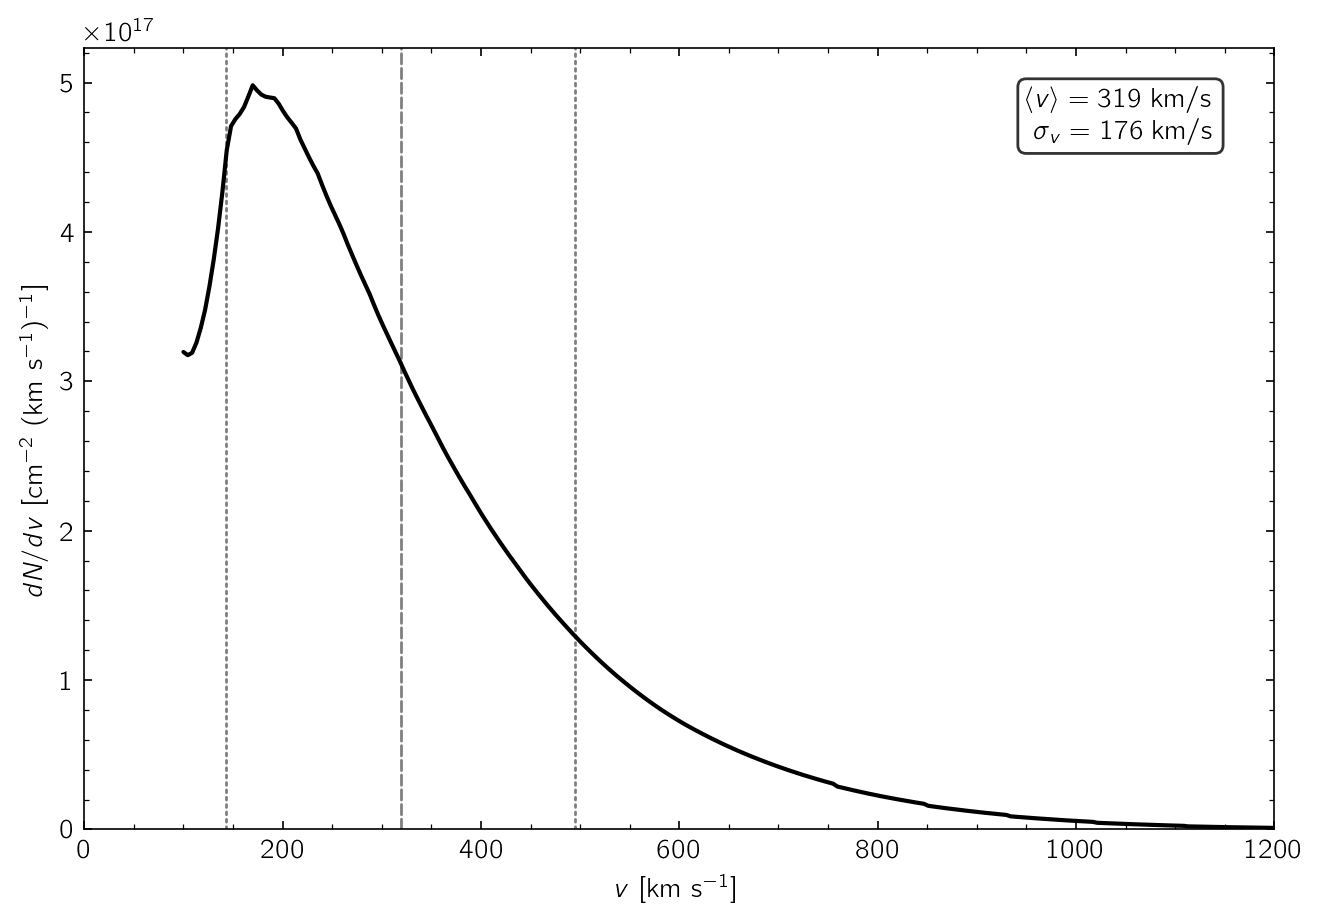

In [14]:
fig_col_total, _ = plot_column_density_distribution(
    solution,
    r_min_kpc=R_MIN_OBS_KPC,
    r_max_kpc=obs_r_max,
    show_moments=True,
    xlim=(0, 1200),
    figsize=(6.5, 4.5),
)

if SAVE_PLOTS:
    fig_col_total.savefig(os.path.join(PLOTS_DIR, "m82_column_density_total.pdf"), dpi=300, bbox_inches="tight")

plt.show()

Set SAVE_PLOTS = True to export PDF files.


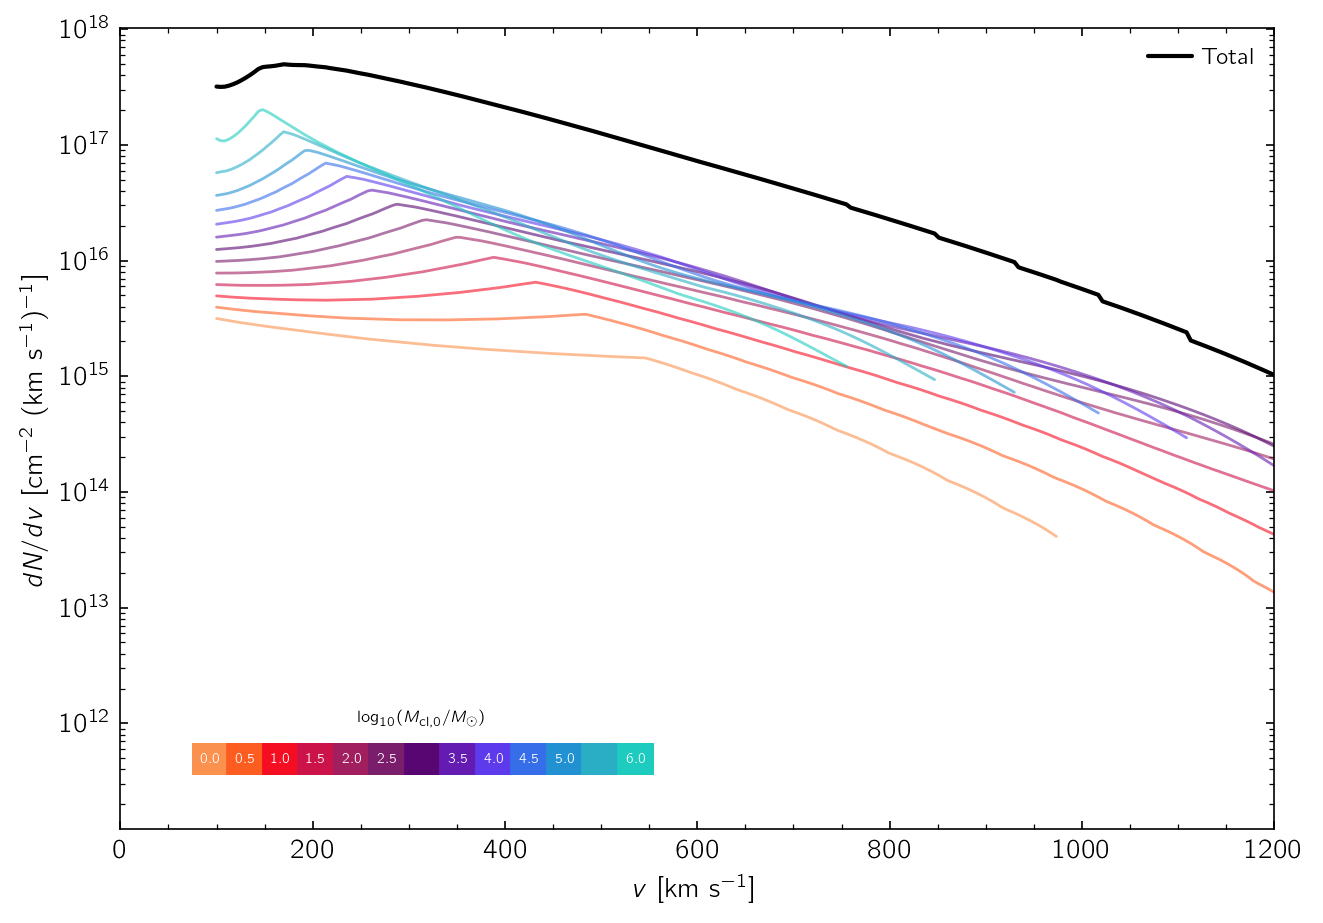

In [15]:
fig_col_species, _ = plot_column_density_distribution(
    solution,
    r_min_kpc=R_MIN_OBS_KPC,
    r_max_kpc=obs_r_max,
    show_species=True,
    species_alpha=0.6,
    log_scale=True,
    xlim=(0, 1200),
    figsize=(6.5, 4.5),
)

if SAVE_PLOTS:
    fig_col_species.savefig(os.path.join(PLOTS_DIR, "m82_column_density_by_species.pdf"), dpi=300, bbox_inches="tight")
    print(f"Saved plots to {PLOTS_DIR}/")
else:
    print("Set SAVE_PLOTS = True to export PDF files.")

plt.show()